## Denoising Autoencoder (DAE)
### Core idea
- Instead of  **x → encoder → z → decoder → x̂**
- We do **x → add noise → x̃ → encoder → z → decoder → x̂**

- **🎯 Goal:**
    - Reconstruct original clean x, not noisy x̃

### Why this is powerful (intuition)

#### Imagine training on faces:
- **Noise = random pixels corrupted**

- Model must:

    - Learn global structure
    - Ignore pixel-level noise
    - Capture stable patterns

- So the model learns:

    - Edges
    - Shapes
    - Manifold of valid data

This is representation learning, not memorization.


### Mathematical formulation
- **Step 1**: Corrupt input **𝑥~ = 𝑥+ 𝜖**. Add any kind of noise to input data x.
    - Gaussian noise
    - Masking noise (set random entries to 0)
    - Salt & pepper noise

- **Step 2**: Encode: **𝑧 = 𝑓(𝑊𝑒 𝑥~ + 𝑏𝑒)**, 
    - 𝑊𝑒 :  enocder weight,
    - 𝑏𝑒 : encoder bias
    - 𝑥~ : noisy corrupted data.
    - z : latent space, = output from encoder.

- **Step 3**: Decode: **𝑥^ = g(𝑊d z + bd​)**
    - Wd : decoder weight
    - bd: decoder bias
    - z: input from latent space
    - 𝑥^ : prediction 

- **Step 4**: Loss (important!): L=∥x−x^∥2
    - **⚠️ Loss compares output to clean x, not noisy input**

#### Why does reconstruction ignore noise?
 - Latenspace during learning must ignore noises
 - **Because noise is inconsistent across samples, structure is consistent** 


    

### Denoising Autoencode from scratch

/opt/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/var/folders/v1/pwt8v94j085ccrztxjd20_1m0000gn/T/ipykernel_18796/1520800034.py:35: RuntimeWarning: invalid value encountered in matmul
  grad_W_d = z.T @ grad_out
/var/folders/v1/pwt8v94j085ccrztxjd20_1m0000gn/T/ipykernel_18796/1520800034.py:39: RuntimeWarning: invalid value encountered in multiply
  grad_z_lin = grad_z * relu_grad(z_lin)
/var/folders/v1/pwt8v94j085ccrztxjd20_1m0000gn/T/ipykernel_18796/1520800034.py:48: RuntimeWarning: invalid value encountered in subtract
  b_d -= lr * grad_b_d


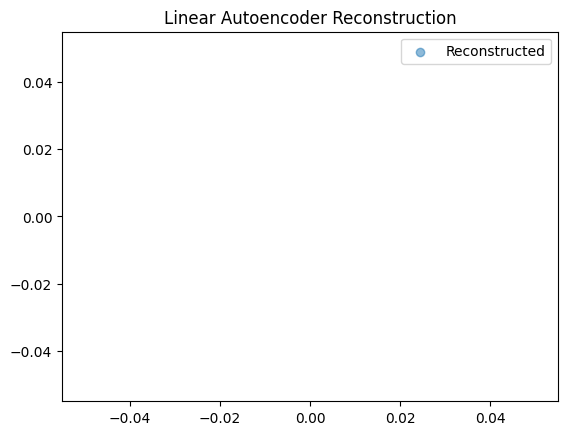

In [3]:
import numpy as np

# Data 
x = np.linspace(-1, 1, 200).reshape(-1, 1)

# Add noise
noise = 0.5 * np.random.randn(*x.shape)
x_noisy = x + noise

# Initialize weights
W_e = np.random.randn(1, 2)
b_e = np.zeros((1, 2))
W_d = np.random.randn(2, 1)
b_d = np.zeros((1, 1))

lr = 0.05

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

# Training
for _ in range(2000):
    # Forward
    z_lin = x_noisy @ W_e + b_e
    z = relu(z_lin)
    x_hat = z @ W_d + b_d

    # Loss gradient
    grad_out = 2 * (x_hat - x)

    # Backprop
    grad_W_d = z.T @ grad_out
    grad_b_d = grad_out.sum(axis=0, keepdims=True)

    grad_z = grad_out @ W_d.T
    grad_z_lin = grad_z * relu_grad(z_lin)

    grad_W_e = x_noisy.T @ grad_z_lin
    grad_b_e = grad_z_lin.sum(axis=0, keepdims=True)

    # Update
    W_e -= lr * grad_W_e
    b_e -= lr * grad_b_e
    W_d -= lr * grad_W_d
    b_d -= lr * grad_b_d

x_reconstructed = relu(x_noisy @ W_e + b_e) @ W_d + b_d

# plot original vs reconstructed
import matplotlib.pyplot as plt
#plt.scatter(x, x, label='Original', alpha=0.5)
plt.scatter(x, x_reconstructed, label='Reconstructed', alpha=0.5)
plt.legend()
plt.title("Linear Autoencoder Reconstruction")
plt.show()


Epoch 1/2000  loss=0.656571
Epoch 250/2000  loss=0.131562
Epoch 500/2000  loss=0.130283
Epoch 750/2000  loss=0.129645
Epoch 1000/2000  loss=0.129375
Epoch 1250/2000  loss=0.129219
Epoch 1500/2000  loss=0.129064
Epoch 1750/2000  loss=0.128904
Epoch 2000/2000  loss=0.128738


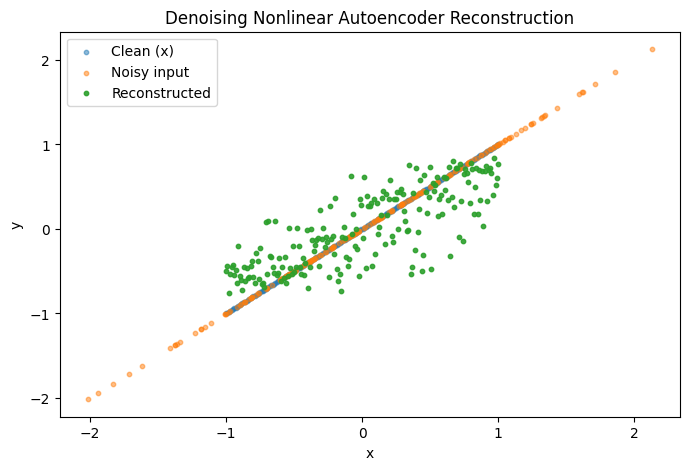

In [4]:
# PyTorch denoising nonlinear autoencoder
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Data (same as before)
x = np.linspace(-1, 1, 200).reshape(-1, 1).astype(np.float32)
noise = 0.5 * np.random.randn(*x.shape).astype(np.float32)
x_noisy = x + noise

# Tensors + device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_t = torch.from_numpy(x).to(device)
x_noisy_t = torch.from_numpy(x_noisy).to(device)

# Model
class DenoisingAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat

model = DenoisingAE(input_dim=x.shape[1], latent_dim=1).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training
n_epochs = 2000
for epoch in range(1, n_epochs + 1):
    model.train()
    opt.zero_grad()
    xhat = model(x_noisy_t)
    loss = loss_fn(xhat, x_t)  # compare to clean x
    loss.backward()
    opt.step()

    if epoch % 250 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{n_epochs}  loss={loss.item():.6f}")

# Inference / visualize
model.eval()
with torch.no_grad():
    x_recon_t = model(x_noisy_t)

x_recon = x_recon_t.cpu().numpy()

plt.figure(figsize=(8, 5))
plt.scatter(x, x, label="Clean (x)", alpha=0.5, s=10)
plt.scatter(x_noisy, x_noisy, label="Noisy input", alpha=0.5, s=10)
plt.scatter(x, x_recon, label="Reconstructed", alpha=0.9, s=10)
plt.legend()
plt.title("Denoising Nonlinear Autoencoder Reconstruction")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Optional: latent space visualization (useful if latent_dim==2)
with torch.no_grad():
    z = model.encoder(torch.from_numpy(x_noisy).to(device)).cpu().numpy()

if z.shape[1] == 2:
    plt.figure(figsize=(5, 4))
    plt.scatter(z[:, 0], z[:, 1], c=x.squeeze(), cmap="viridis", s=20)
    plt.colorbar(label="x value")
    plt.title("Latent space (colored by x)")
    plt.show()

In [ ]:
# Clean data: y = x^2
x = np.linspace(-1, 1, 300)
data = np.vstack([x, x**2]).T  # shape (300, 2)

# Add noise
noise = 0.1 * np.random.randn(*data.shape)
data_noisy = data + noise



array([[-1.        ],
       [-0.98994976],
       [-0.9798995 ],
       [-0.9698492 ],
       [-0.959799  ],
       [-0.94974875],
       [-0.9396985 ],
       [-0.9296482 ],
       [-0.919598  ],
       [-0.90954775],
       [-0.8994975 ],
       [-0.8894472 ],
       [-0.879397  ],
       [-0.86934674],
       [-0.8592965 ],
       [-0.8492462 ],
       [-0.83919597],
       [-0.8291457 ],
       [-0.8190955 ],
       [-0.80904526],
       [-0.79899496],
       [-0.7889447 ],
       [-0.7788945 ],
       [-0.76884425],
       [-0.75879395],
       [-0.7487437 ],
       [-0.7386935 ],
       [-0.72864324],
       [-0.71859294],
       [-0.7085427 ],
       [-0.69849247],
       [-0.68844223],
       [-0.67839193],
       [-0.6683417 ],
       [-0.65829146],
       [-0.6482412 ],
       [-0.6381909 ],
       [-0.6281407 ],
       [-0.61809045],
       [-0.6080402 ],
       [-0.59799   ],
       [-0.5879397 ],
       [-0.57788944],
       [-0.5678392 ],
       [-0.55778897],
       [-0